# Regresión lineal

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Cargar datos

In [13]:
df = pd.read_csv('computadoras.csv')
df = df.dropna()

### Separar datos: 80% entrenar, 20% pruebas

In [14]:
X = df[['Año']] # Lo que conocemos
y = df[['Precio']] # Lo que queremos predecir

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Datos listos")
print(f"Datos de entrenamiento: ${len(X_train)}")
print(f"Datos de prueba: ${len(X_test)}")

Datos listos
Datos de entrenamiento: $1200
Datos de prueba: $300


## Entrenar el modelo

In [15]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-4.79]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Año']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[12245.27]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


### Gráfico de tendencia

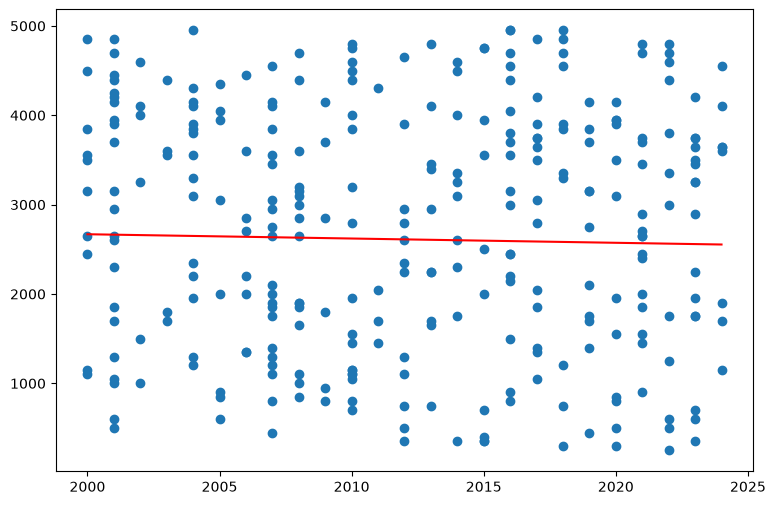

In [16]:
X_test_sorted = X_test.sort_values(by='Año')

plt.figure(figsize=[9, 6])
plt.scatter(X_test, y_test)
plt.plot(X_test_sorted, modelo.predict(X_test_sorted),  color='red')

### ¿Qué aprendió el modelo?

In [17]:
cambio_por_anio = modelo.coef_[0]

if cambio_por_anio < 0:
    print(f"Cada año que pasa el precio baja ${abs(cambio_por_anio)}")
else:
    print(f"Cada año que pasa el precio sube ${cambio_por_anio}")

Cada año que pasa el precio baja $[4.7882114]


### Despliegue

#### Usar el modelo

In [18]:
anio = 2025
precio = modelo.predict([[anio]])[0]
print(f" Un equipo del año ${anio} costaría ${precio}")

 Un equipo del año $2025 costaría $[2549.14045198]


c:\Users\alexd\ITSQMET\Desarrollo de Software\Inteligencia Artificial\Clases\script-03\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Evaluar

In [19]:
predicciones = modelo.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
r2 = modelo.score(X_test, y_test)

print("METRICAS")
print(f"Error medio absoluto (MAE): ${mae}")
print(f"En promedio el modelo erró esa cantidad \n")
# r = 0%
# r = 100% modelo perfecto entre más cerca mejor
print(f"R cuadrado (R²): ${r2}")
print(f"El año explica el ${r2*100}% de la variación del precio")

NameError: name 'mean_absolute_error' is not defined